# Natural Language Processing

## Problem Statement 

Stock Market News Sentiment Analysis and Summarization

### Data Dictionary 

The dataset contains the following data - 

- Date: The date the news was released
- News: The content of news articles that could potentially affect the company's stock price
- Open: The stock price (in dollars) at the beginning of the day
- High: The highest stock price (in dollars) reached during the day
- Low: The lowest stock price (in dollars) reached during the day
- Close: The adjusted stock price (in dollars) at the end of the day
- Volume: The number of shares traded during the day
- Label: The sentiment polarity of the news content
    - 1: Positive
    - 0: Neutral
    - -1: Negative

### Let us import some essential libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split,GridSearchCV
import gensim
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import nltk
nltk.download("punkt")

from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from transformers import pipeline
import json
import transformers
import torch
torch.backends.cuda.enable_mem_efficient_sdp(False)
torch.backends.cuda.enable_flash_sdp(False)
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, classification_report



[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
2025-08-24 11:00:36.686349: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756033236.892953      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756033236.954166      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
data = pd.read_csv("/kaggle/input/stock-news/stock_news.csv")

In [3]:
data.columns

Index(['Date', 'News', 'Open', 'High', 'Low', 'Close', 'Volume', 'Label'], dtype='object')

In [4]:
data.shape

(349, 8)

### Observations

There are 349 rows and 8 columns

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


### Observations 

- Date & News are of object datatype
- Open, High,Low and Close of float64 datatype
- Volume,Label are of int64 datatype

In [6]:
data.describe(include ='all')

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Date,News,Open,High,Low,Close,Volume,Label
count,349,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
unique,71,349,NaN,NaN,NaN,NaN,NaN,NaN
top,2019-01-03,"In the first quarter, South Korea's Samsung E...",NaN,NaN,NaN,NaN,NaN,NaN
freq,28,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
std,NaN,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119
min,NaN,NaN,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,NaN,NaN,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,NaN,NaN,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,NaN,NaN,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000


### Observations 

- Date has 71 unique values, since there maybe multiple trades on a single day.
- News has 349 unique values, indicating no duplicate news are present.
- Open,High,Low,Close have big different min and max value, however the mean and std are relatively similar
- Vomue have enourmous values, suggesting that volumes of trades are huge.
- Labels might require some balancing since difference between 75 percentile and max value is more.

In [7]:
data.isnull().sum()

Date      0
News      0
Open      0
High      0
Low       0
Close     0
Volume    0
Label     0
dtype: int64

### Observations 

- There are no null values

In [8]:
data.duplicated().sum()

0

### Observations 

- There are no duplicates in the dataset

## EDA - Univariate Analysis

<Axes: xlabel='Close'>

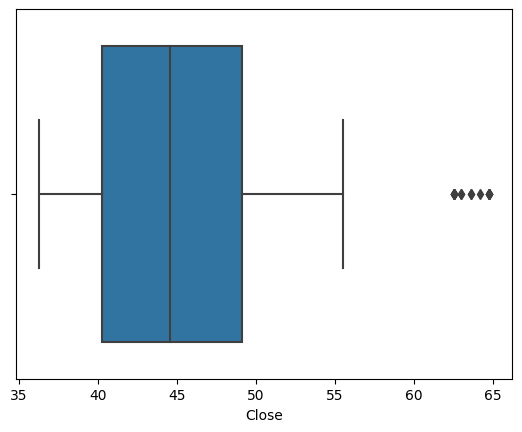

In [9]:
#plotting boxplot for close variable
sns.boxplot(data,x="Close")

### Observations

- There are certain outliers which makes sense due to different closing prices for the stock

<Axes: xlabel='Open'>

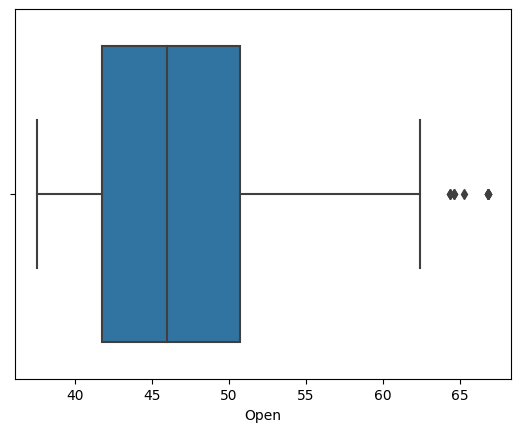

In [10]:
#plotting boxplot for Open variable
sns.boxplot(data,x="Open")

### Observations 

- There are certain outliers which makes sense due to different opening prices for the stock

<Axes: xlabel='High'>

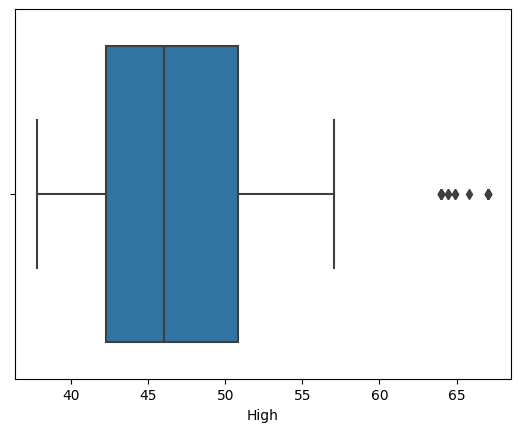

In [11]:
#plotting boxplot for High variable
sns.boxplot(data,x="High")

### Observations 

- There are outliers since the high price varies for different news articles 

<Axes: xlabel='Low'>

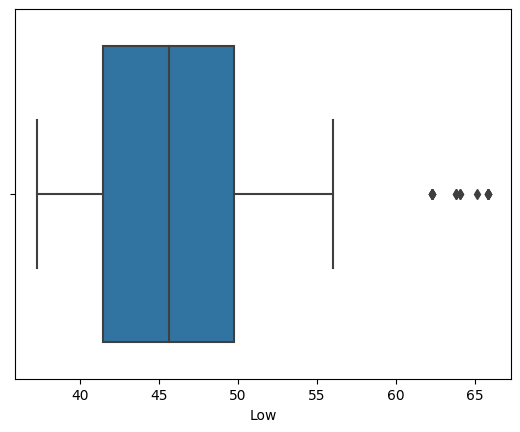

In [12]:
#plotting boxplot for Low variable
sns.boxplot(data,x="Low")

### Observations 

- There are outliers since the low price varies for different news articles 

<Axes: xlabel='Volume'>

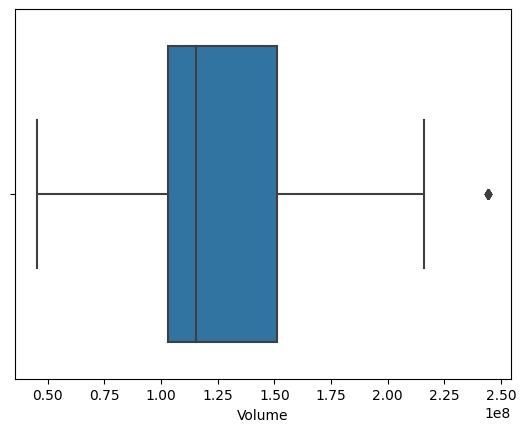

In [13]:
#plotting boxplot for volumes
sns.boxplot(data,x='Volume')

### Observations 

- The data looks left skewed which means that there are less trades with high volumes and high trades with low volumes, suggesting risk appetite.
- There a outlier suggesting that is some very huge trades as well.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Label', ylabel='Count'>

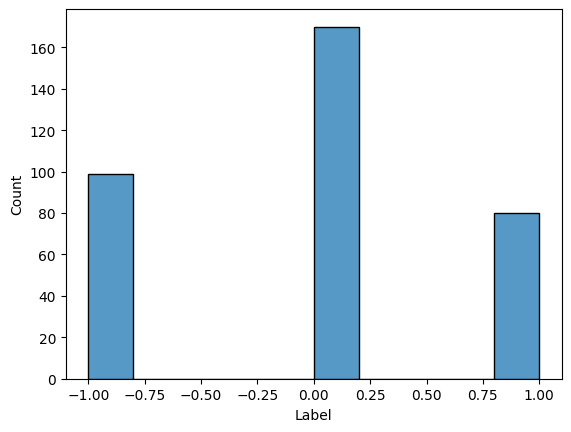

In [14]:
#plotting histogram for label
sns.histplot(data,x='Label')

### Observations 

- There are much more neutral sentiments as compared to positive and negative sentiments
- It might require some balancing while training a supervised ML model.

## EDA - Bivarite and Multivariate Analysis

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

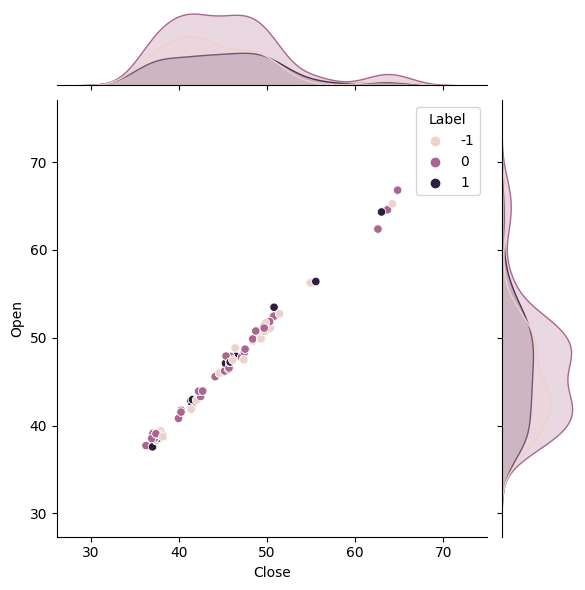

In [15]:
#analyzing the close and open over sentiments

sns.jointplot(data=data,x='Close',y='Open',hue = 'Label')

### Observations 

- There have been relatively less trades for higher open and close prices as compared to low close and open prices.
- News sentiment have not hit the markets on the same day as much hence the difference between the closing and opening price is not much.

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

<Axes: xlabel='High', ylabel='Low'>

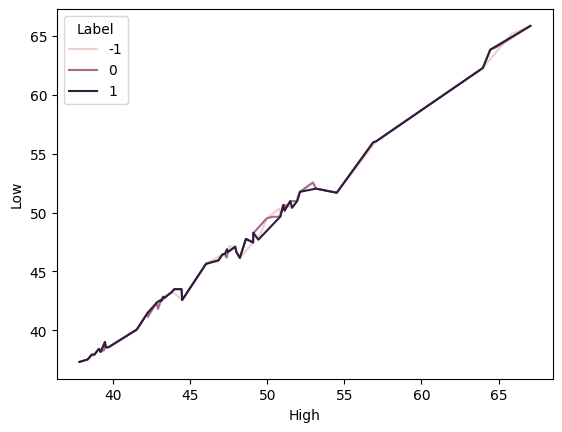

In [16]:
#analyzing the high and low over sentiments

sns.lineplot(data=data,x='High',y='Low',hue = 'Label')

### Observations

- Trades do rise if the news is positive while staying a little low if the sentiments are neutral

/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


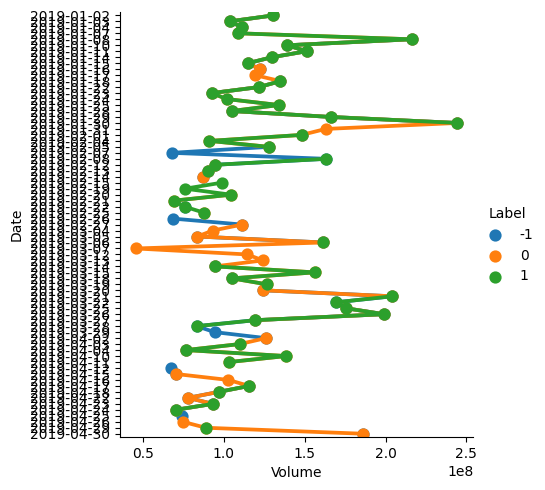

In [17]:
#analyze the date with the volumes across sentiments
sns.catplot(data=data,x='Volume',y='Date',hue='Label',kind='point');

### Observations 

- For positive sentiments, there is more volume of trades when negative sentiments
- There are instances of high trades which sentiment is neutral suggesting some insider news as well.

<Axes: >

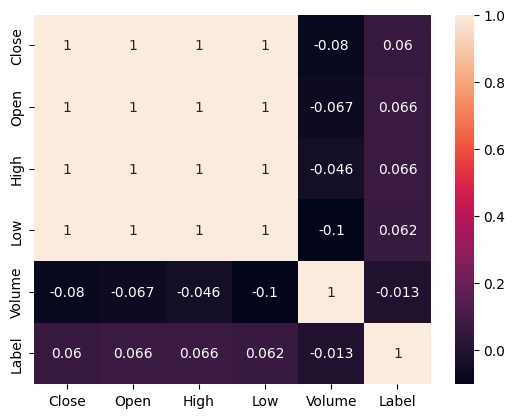

In [18]:
# analyze the correlations between variables
sns.heatmap(data=data[['Close','Open','High','Low','Volume','Label']].corr(),annot=True)

### Observations 

- There is negative correlation between volume and the rest.
- However, label has positive correlation with low,high,close and open
- Low,High,Close,Open has 100% positive correlation

## Conversion to Word Embeddings using different models

### Word2Vec

In [19]:
def get_w2v_embedding(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) > 0:
        return sum(vectors) / len(vectors)
    else:
        return [0] * model.vector_size

data["Tokens"] = data["News"].apply(lambda x: word_tokenize(str(x).lower()))
w2v_model = Word2Vec(sentences=data["Tokens"], vector_size=100, window=5, workers=4,sg=1)
data["Word2vec_embedding_news"] = data["Tokens"].apply(lambda x: get_w2v_embedding(x, w2v_model))

In [20]:
data.head()

,Date,News,Open,High,Low,Close,Volume,Label,Tokens,Word2vec_embedding_news
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1,"[the, tech, sector, experienced, a, significan...","[-0.06351722, 0.043769993, 0.055770062, 0.0149..."
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1,"[apple, lowered, its, fiscal, q1, revenue, gui...","[-0.063763164, 0.04031698, 0.053223357, 0.0125..."
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1,"[apple, cut, its, fiscal, first, quarter, reve...","[-0.06371462, 0.039784465, 0.053445894, 0.0120..."
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1,"[this, news, article, reports, that, yields, o...","[-0.06084033, 0.044367243, 0.053619333, 0.0132..."
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1,"[apple, 's, revenue, warning, led, to, a, decl...","[-0.065181285, 0.03791366, 0.056429423, 0.0135..."


### Observations 

- Considering the context window size as 5 since the news paragraphs are small paragraphs.
- Using the skip-gram logic to capture the rare appearing words since that would be essential for sentiment analysis as against continuous bag of words.

## GloVE Model

In [21]:
embeddings_index = {}
with open("/kaggle/input/glove_model/pytorch/default/1/glove.6B.100d.txt.word2vec", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

def get_glove_embedding(tokens, embeddings_index, dim=100):
    vectors = [embeddings_index[word] for word in tokens if word in embeddings_index]
    if len(vectors) > 0:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(dim)

data["GloVE_embedding_news"] = data["Tokens"].apply(lambda x: get_glove_embedding(x, embeddings_index, 100))

In [22]:
data.head()

,Date,News,Open,High,Low,Close,Volume,Label,Tokens,Word2vec_embedding_news,GloVE_embedding_news
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1,"[the, tech, sector, experienced, a, significan...","[-0.06351722, 0.043769993, 0.055770062, 0.0149...","[0.017698549, 0.01978574, 0.2704169, -0.166335..."
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1,"[apple, lowered, its, fiscal, q1, revenue, gui...","[-0.063763164, 0.04031698, 0.053223357, 0.0125...","[0.089587756, 0.24848291, 0.30326682, -0.03383..."
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1,"[apple, cut, its, fiscal, first, quarter, reve...","[-0.06371462, 0.039784465, 0.053445894, 0.0120...","[0.08615657, 0.2397572, 0.3853554, -0.10700309..."
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1,"[this, news, article, reports, that, yields, o...","[-0.06084033, 0.044367243, 0.053619333, 0.0132...","[-0.04770504, 0.11956853, 0.4791461, -0.076513..."
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1,"[apple, 's, revenue, warning, led, to, a, decl...","[-0.065181285, 0.03791366, 0.056429423, 0.0135...","[0.07121915, 0.16935442, 0.31919253, -0.042520..."


### Observations 

- Already had a pre-built glove model given by Great Lakes team which has to been incorporated into building vectors for entire news corpus.
- Used to take the mean of entire word vector to form entire news article embedding from GloVE.

## Sentence Transformer - all-MiniLM-L6-v2

In [ ]:
model = SentenceTransformer("all-MiniLM-L6-v2")
data["sentence_transformer_embedding_news"] = data["News"].apply(lambda x: model.encode(str(x)))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
data.head()

,Date,News,Open,High,Low,Close,Volume,Label,sentence_transformer_embedding_news
0,2019-01-02,The tech sector experienced a significant dec...,41.740002,42.244999,41.482498,40.246914,130672400,-1,"[-0.0020230813, -0.036773518, 0.07735433, 0.04..."
1,2019-01-02,Apple lowered its fiscal Q1 revenue guidance ...,41.740002,42.244999,41.482498,40.246914,130672400,-1,"[0.013749409, 0.048933998, 0.089868344, 0.0477..."
2,2019-01-02,Apple cut its fiscal first quarter revenue fo...,41.740002,42.244999,41.482498,40.246914,130672400,-1,"[0.03097598, 0.0026355477, 0.09013869, 0.06571..."
3,2019-01-02,This news article reports that yields on long...,41.740002,42.244999,41.482498,40.246914,130672400,-1,"[-0.0052941227, -0.009259265, -0.009669866, 0...."
4,2019-01-02,Apple's revenue warning led to a decline in U...,41.740002,42.244999,41.482498,40.246914,130672400,-1,"[-0.0021458014, 0.016796734, -0.0040655336, 0...."


### Observations 

- In Word2Vec and GloVE, had to take the mean of all embeddings to represent the entire article as a single embedding while SentenceTransformer has it built within.
- In SentenceTransformer model - all-MiniLM-L6-v2 is a BERT model made of encoder architecture of the transformer model hence understanding the nuanced aspects of the news articles.

## Data Pre-processing

In [25]:
#splitting the data into target colums
X = data.drop(columns = ['Label'])
y= data['Label']

In [26]:
#Splitting into train and test data
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [27]:
#Splitting into train and validation data
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42
)

## Sentiment Analysis - Model Building

In [28]:
# defining a function to compute different metrics
def model_performance(model, predictors, target):

    pred = model.predict(predictors)

    acc = accuracy_score(target, pred) 
    recall = recall_score(target, pred, average='weighted') 
    precision = precision_score(target, pred, average='weighted') 
    f1 = f1_score(target, pred, average='weighted')

    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

### Observations 

- Accuracy metric helps in gauging the overall accuracy of the model.
- Precision and Recall are the metrics used to gauge the correctly predicted True Positives and True Negatives.
- F1-score - helps in calculating the overall precision and recall.

### Building model with Word2Vec

In [29]:
# Label Encoding
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_val_enc = encoder.fit_transform(y_val)
y_test_enc = encoder.transform(y_test)

#Trimming the data to only the essential information
expanded_df = pd.DataFrame(X_train["Word2vec_embedding_news"].tolist(), index=X_train.index)
expanded_df.columns = [f"Word2vec_embedding_news_dim_{i}" for i in range(expanded_df.shape[1])]
X_train_word2vec = X_train.drop(columns=["Date","News","Tokens","Word2vec_embedding_news","GloVE_embedding_news","sentence_transformer_embedding_news"])

expanded_df = pd.DataFrame(X_val["Word2vec_embedding_news"].tolist(), index=X_val.index)
expanded_df.columns = [f"Word2vec_embedding_news_dim_{i}" for i in range(expanded_df.shape[1])]
X_val_word2vec = X_val.drop(columns=["Date","News","Tokens","Word2vec_embedding_news","GloVE_embedding_news","sentence_transformer_embedding_news"])

expanded_df = pd.DataFrame(X_test["Word2vec_embedding_news"].tolist(), index=X_test.index)
expanded_df.columns = [f"Word2vec_embedding_news_dim_{i}" for i in range(expanded_df.shape[1])]
X_test_word2vec = X_test.drop(columns=["Date","News","Tokens","Word2vec_embedding_news","GloVE_embedding_news","sentence_transformer_embedding_news"])

In [30]:
xgb_word2vec = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    use_label_encoder=False,
)

xgb_word2vec.fit(X_train_word2vec,y_train_enc,eval_set=[(X_val_word2vec, y_val_enc)],verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=3, num_parallel_tree=None, ...)

In [31]:
y_pred_word2vec = xgb_word2vec.predict(X_test_word2vec)

In [32]:
#Calculating different metrics on training data
xgb_word2vec_train=model_performance(xgb_word2vec, X_train_word2vec,y_train_enc)
print("Training performance:\n", xgb_word2vec_train)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.641148  0.641148   0.642929  0.626259


In [33]:
#Calculating different metrics on testing data
xgb_word2vec_test=model_performance(xgb_word2vec, X_test_word2vec,y_test_enc)
print("Testing performance:\n", xgb_word2vec_test)

Testing performance:
    Accuracy    Recall  Precision       F1
0  0.371429  0.371429   0.358369  0.36381


### Observations

- The difference between the metrics for training and testing data seems to high suggesting that the model has overfit
- The validation data fed has not helped in reducing loss to high a good extent.

### Building model with GloVE

In [34]:
#Trimming the data to only the essential information
expanded_df = pd.DataFrame(X_train["GloVE_embedding_news"].tolist(), index=X_train.index)
expanded_df.columns = [f"GloVE_embedding_news_dim_{i}" for i in range(expanded_df.shape[1])]
X_train_glove = X_train.drop(columns=["Date","News","Tokens","Word2vec_embedding_news","GloVE_embedding_news","sentence_transformer_embedding_news"])

expanded_df = pd.DataFrame(X_val["GloVE_embedding_news"].tolist(), index=X_val.index)
expanded_df.columns = [f"GloVE_embedding_news_news_dim_{i}" for i in range(expanded_df.shape[1])]
X_val_glove = X_val.drop(columns=["Date","News","Tokens","Word2vec_embedding_news","GloVE_embedding_news","sentence_transformer_embedding_news"])

expanded_df = pd.DataFrame(X_test["GloVE_embedding_news"].tolist(), index=X_test.index)
expanded_df.columns = [f"GloVE_embedding_news_dim_{i}" for i in range(expanded_df.shape[1])]
X_test_glove = X_test.drop(columns=["Date","News","Tokens","Word2vec_embedding_news","GloVE_embedding_news","sentence_transformer_embedding_news"])

In [35]:
xgb_glove = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    use_label_encoder=False,
)

xgb_glove.fit(X_train_glove,y_train_enc,eval_set=[(X_val_glove, y_val_enc)],verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=3, num_parallel_tree=None, ...)

In [36]:
y_pred_glove = xgb_glove.predict(X_test_glove)

In [37]:
#Calculating different metrics on training data
xgb_glove_train=model_performance(xgb_glove, X_train_glove,y_train_enc)
print("Training performance:\n", xgb_glove_train)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.641148  0.641148   0.642929  0.626259


In [38]:
#Calculating different metrics on training data
xgb_glove_test=model_performance(xgb_glove, X_test_glove,y_test_enc)
print("Testing performance:\n", xgb_glove_test)

Testing performance:
    Accuracy    Recall  Precision       F1
0  0.371429  0.371429   0.358369  0.36381


### Observations

- The difference between the metrics for training and testing data seems to high suggesting that the model has overfit
- The validation data fed has not helped in reducing loss to high a good extent.

### Building model with SentenceTransformer

In [39]:
#Trimming the data to only the essential information
expanded_df = pd.DataFrame(X_train["sentence_transformer_embedding_news"].tolist(), index=X_train.index)
expanded_df.columns = [f"sentence_transformer_embedding_news_dim_{i}" for i in range(expanded_df.shape[1])]
X_train_sentence_transformer = X_train.drop(columns=["Date","News","Tokens","Word2vec_embedding_news","GloVE_embedding_news","sentence_transformer_embedding_news"])

expanded_df = pd.DataFrame(X_val["sentence_transformer_embedding_news"].tolist(), index=X_val.index)
expanded_df.columns = [f"sentence_transformer_embedding_news_dim_{i}" for i in range(expanded_df.shape[1])]
X_val_sentence_transformer = X_val.drop(columns=["Date","News","Tokens","Word2vec_embedding_news","GloVE_embedding_news","sentence_transformer_embedding_news"])

expanded_df = pd.DataFrame(X_test["sentence_transformer_embedding_news"].tolist(), index=X_test.index)
expanded_df.columns = [f"sentence_transformer_embedding_news_dim_{i}" for i in range(expanded_df.shape[1])]
X_test_sentence_transformer = X_test.drop(columns=["Date","News","Tokens","Word2vec_embedding_news","GloVE_embedding_news","sentence_transformer_embedding_news"])

In [40]:
xgb_sentence_transformer = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    use_label_encoder=False,
)

xgb_sentence_transformer.fit(X_train_sentence_transformer,y_train_enc,eval_set=[(X_val_sentence_transformer, y_val_enc)],verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=3, num_parallel_tree=None, ...)

In [41]:
y_pred_sentence_transformer = xgb_sentence_transformer.predict(X_test_sentence_transformer)

In [42]:
#Calculating different metrics on training data
xgb_sentence_transformer_train=model_performance(xgb_sentence_transformer, X_train_sentence_transformer,y_train_enc)
print("Training performance:\n", xgb_sentence_transformer_train)

Training performance:
    Accuracy    Recall  Precision        F1
0  0.641148  0.641148   0.642929  0.626259


In [43]:
#Calculating different metrics on testing data
xgb_sentence_transformer_test=model_performance(xgb_sentence_transformer, X_test_sentence_transformer,y_test_enc)
print("Testing performance:\n", xgb_sentence_transformer_test)

Testing performance:
    Accuracy    Recall  Precision       F1
0  0.371429  0.371429   0.358369  0.36381


### Observations

- The difference between the metrics for training and testing data seems to high suggesting that the model has overfit
- The validation data fed has not helped in reducing loss to high a good extent.

## Hyperparameter Tuning - XgBoost Model

### Tuning wordtovec base XGBoost model

In [44]:
param_grid_word2vec = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
}

In [45]:
grid_word2vec = GridSearchCV(
    estimator=xgb_word2vec,
    param_grid=param_grid_word2vec,
    scoring="f1_macro",
    cv=3,
)

grid_word2vec.fit(
    X_train_word2vec, y_train_enc,
    eval_set=[(X_val_word2vec, y_val_enc)],
    verbose=False,
)

best_model_word2vec = grid_word2vec.best_estimator_
print("Best Parameters:", grid_word2vec.best_params_)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}


In [46]:
#Calculating different metrics on training data
best_model_word2vec_train=model_performance(best_model_word2vec, X_train_word2vec,y_train_enc)
print("Training_performance:\n", best_model_word2vec_train)

Training_performance:
    Accuracy    Recall  Precision        F1
0  0.617225  0.617225   0.637245  0.587919


In [47]:
#Calculating different metrics on testing data
best_model_word2vec_test=model_performance(best_model_word2vec, X_test_word2vec,y_test_enc)
print("Testing_performance:\n", best_model_word2vec_test)

Testing_performance:
    Accuracy    Recall  Precision        F1
0  0.457143  0.457143   0.433952  0.429299


### Observations

- The model overfitting seems to have dropped based on the f1-score

### Tuning GloVe XGBoost base model

In [48]:
param_grid_glove = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
}

In [49]:
grid_glove = GridSearchCV(
    estimator=xgb_word2vec,
    param_grid=param_grid_word2vec,
    scoring="f1_macro",
    cv=3,
)

grid_glove.fit(
    X_train_glove, y_train_enc,
    eval_set=[(X_val_glove, y_val_enc)],
    verbose=False,
)

best_model_glove = grid_glove.best_estimator_
print("Best Parameters:", grid_glove.best_params_)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100}


In [50]:
#Calculating different metrics on training data
best_model_glove_train=model_performance(best_model_glove, X_train_glove,y_train_enc)
print("Training_performance:\n", best_model_glove_train)

Training_performance:
    Accuracy    Recall  Precision        F1
0  0.617225  0.617225   0.637245  0.587919


In [51]:
#Calculating different metrics on testing data
best_model_glove_test=model_performance(best_model_glove, X_test_glove,y_test_enc)
print("Testing_performance:\n", best_model_glove_test)

Testing_performance:
    Accuracy    Recall  Precision        F1
0  0.457143  0.457143   0.433952  0.429299


### Observations

- The model overfitting seems to have dropped based on the f1-score.
- Not much difference it terms of scores from word2vec model embeddings

### Tuning Sentence Transformer XGBoost base model

In [52]:
param_grid_sentence_transformer = {
    "n_estimators": [100,150, 200,500],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.001,0.01, 0.05,0.1],
}

In [53]:
grid_sentence_transformer = GridSearchCV(
    estimator=xgb_sentence_transformer,
    param_grid=param_grid_sentence_transformer,
    scoring="f1_macro",
    cv=3,
)

grid_sentence_transformer.fit(
    X_train_sentence_transformer, y_train_enc,
    eval_set=[(X_val_sentence_transformer, y_val_enc)],
    verbose=False,
)

best_model_sentence_transformer = grid_sentence_transformer.best_estimator_
print("Best Parameters:", grid_sentence_transformer.best_params_)

Best Parameters: {'learning_rate': 0.01, 'max_depth': 9, 'n_estimators': 100}


In [54]:
#Calculating different metrics on training data
best_model_sentence_transformer_train=model_performance(best_model_sentence_transformer, X_train_sentence_transformer,y_train_enc)
print("Training_performance:\n", best_model_sentence_transformer_train)

Training_performance:
    Accuracy    Recall  Precision        F1
0  0.636364  0.636364   0.629595  0.625821


In [55]:
#Calculating different metrics on testing data
best_model_sentence_transformer_test=model_performance(best_model_sentence_transformer, X_test_sentence_transformer,y_test_enc)
print("Testing_performance:\n", best_model_sentence_transformer_test)

Testing_performance:
    Accuracy    Recall  Precision        F1
0  0.385714  0.385714   0.380543  0.382817


### Observations

- For sentence transformers, the overfitting still persists, hence we might need to use another model.

In [56]:
#comparing the training for different models
best_model_train = pd.concat([best_model_word2vec_train,best_model_glove_train,best_model_sentence_transformer_train],axis=0,keys=["Word2Vec", "GloVe", "SentenceTransformer"])
print("Training performance across all the best models:\n", best_model_train)

Training performance across all the best models:
                        Accuracy    Recall  Precision        F1
Word2Vec            0  0.617225  0.617225   0.637245  0.587919
GloVe               0  0.617225  0.617225   0.637245  0.587919
SentenceTransformer 0  0.636364  0.636364   0.629595  0.625821


In [57]:
#comparing the testing for different models
best_model_test = pd.concat([best_model_word2vec_test,best_model_glove_test,best_model_sentence_transformer_test],axis=0,keys=["Word2Vec", "GloVe", "SentenceTransformer"])
print("Testing performance across all the best models:\n", best_model_test)

Testing performance across all the best models:
                        Accuracy    Recall  Precision        F1
Word2Vec            0  0.457143  0.457143   0.433952  0.429299
GloVe               0  0.457143  0.457143   0.433952  0.429299
SentenceTransformer 0  0.385714  0.385714   0.380543  0.382817


### Observations

- Sentence Transformer has high training scores but test scores are pretty less suggesting that the model has overfit even after hyperparameter tuning suggesting to us maybe some other classifier model.
- Word2vec and Glove have similar scores and have shown reasonably less overfitting, however, maybe the usage of another classifier model might bring it down even further.

## Content Summarization - Model Building

In [4]:
#group by week
data['Date'] = pd.to_datetime(data['Date'],errors = "coerce")
data["Content"] = (
    "News Content is - " + data["News"].astype(str) + ". " +
    "The High price is  " + data["High"].astype(str) + ". " +
    "The Low price is " + data["Low"].astype(str) + ". " +
    "The Close price is " + data["Close"].astype(str) + ". " +
    "The Open price is " + data["Open"].astype(str)
)

data_grouped_weekly = (
    data.groupby(pd.Grouper(key="Date", freq="W"))["Content"]
    .apply(lambda x: " ".join(x))
    .reset_index()
)

In [5]:
data_grouped_weekly

,Date,Content
0,2019-01-06,News Content is - The tech sector experienced...
1,2019-01-13,News Content is - Sprint and Samsung plan to ...
2,2019-01-20,News Content is - The U.S. stock market decli...
3,2019-01-27,News Content is - The Swiss National Bank (SN...
4,2019-02-03,News Content is - Caterpillar Inc reported lo...
5,2019-02-10,News Content is - The Dow Jones Industrial Av...
6,2019-02-17,"News Content is - This week, the European Uni..."
7,2019-02-24,News Content is - This news article discusses...
8,2019-03-03,News Content is - The Dow Jones Industrial Av...
9,2019-03-10,"News Content is - Spotify, the world's larges..."


In [5]:
model_id = "gpt2-large"

pipeline = transformers.pipeline(
    "text-generation",
    model=model_id,
    device_map="auto",
)

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0


In [39]:
def summarize_events(text, top_k=3):
    instruction = f"""
    Identify the **top {top_k} positive** and **top {top_k} negative** events 
    that are likely to impact the stock price.

    Provide output in JSON format with keys: "positive_events" and "negative_events".

    Content : {text}
    """

    response = pipeline(
    instruction,
    max_new_tokens=200,
)
    return response[0]['generated_text']

In [40]:
from transformers import AutoTokenizer

# GPT-2 large tokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2-large")
MAX_TOKENS = 512   # GPT-2 limit

# Apply truncation before summarization
data_grouped_weekly['Summary'] = data_grouped_weekly['Content'].apply(lambda x: summarize_events(x, tokenizer, MAX_TOKENS))


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

In [43]:
data_grouped_weekly

,Date,Content,Summary
0,2019-01-06,News Content is - The tech sector experienced...,\n Identify the **top 3 positive** and **to...
1,2019-01-13,News Content is - Sprint and Samsung plan to ...,\n Identify the **top 3 positive** and **to...
2,2019-01-20,News Content is - The U.S. stock market decli...,\n Identify the **top 3 positive** and **to...
3,2019-01-27,News Content is - The Swiss National Bank (SN...,\n Identify the **top 3 positive** and **to...
4,2019-02-03,News Content is - Caterpillar Inc reported lo...,\n Identify the **top 3 positive** and **to...
5,2019-02-10,News Content is - The Dow Jones Industrial Av...,\n Identify the **top 3 positive** and **to...
6,2019-02-17,"News Content is - This week, the European Uni...",\n Identify the **top 3 positive** and **to...
7,2019-02-24,News Content is - This news article discusses...,\n Identify the **top 3 positive** and **to...
8,2019-03-03,News Content is - The Dow Jones Industrial Av...,\n Identify the **top 3 positive** and **to...
9,2019-03-10,"News Content is - Spotify, the world's larges...",\n Identify the **top 3 positive** and **to...


In [45]:
def extract_events(output_text):
    try:
        json_start = output_text.find("{")
        json_end = output_text.rfind("}") + 1
        json_str = output_text[json_start:json_end]
        parsed = json.loads(json_str)
        return parsed
    except:
        return {"positive_events": [], "negative_events": []}

data_grouped_weekly['Parsed'] = data_grouped_weekly['Summary'].apply(extract_events)

In [50]:
structured_data_weekly = pd.DataFrame([
    {
        "week_start": row['Date'],
        "positive_events": row['Parsed'].get("positive_events", []),
        "negative_events": row['Parsed'].get("negative_events", [])
    }
    for _, row in data_grouped_weekly.iterrows()
])

print(structured_data_weekly.head())

   week_start                                    positive_events  \
0  2019-01-06  [Roku expanded The Roku Channel with premium s...   
1  2019-01-13  [Sprint and Samsung announced plans to launch ...   
2  2019-01-20  [Dialog Semiconductor reported Q4 revenue in l...   
3  2019-01-27  [IBM’s stock price rose after better-than-expe...   
4  2019-02-03  [Apple announced spending over $60 billion wit...   

                                     negative_events  
0  [Apple cut its Q1 revenue forecast to $84B due...  
1  [Geely forecast flat sales in 2019 after missi...  
2  [U.S. stock markets fell on Monday as Chinese ...  
3  [The Swiss National Bank governor Andrea Maech...  
4  [Caterpillar reported disappointing earnings a...  


## Actionable insights and Recommendations

- The classification model to be used should be a rather simple rather than ensemble of models so that the model does not overfit on the embeddings being created.
- The LLM model used should be first fine-tuned over the plain vanila version since it hallucinates and ends abruptly therefore finetuning helps in generating use-case specific answers
- Embedding model used in sync with large language models make more since due to architecture complexity helping in capturing the entire essence of the model.
- Using a proper infrastructure helps in adequate deployment of the base model utilizing a maximum potential in terms of context window.